<a href="https://colab.research.google.com/github/pedrorostagno/tesis/blob/main/Sesgos_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve


drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/Tesis UTDT/experimentos/20251003-021504_CNN_FT/predictions_test_10k_with_race.csv'

df = pd.read_csv(CSV_PATH)

# Borrar registros con 'race' = 'undetected'
df = df[df['race'] != 'undetected']

print(df.head())


Mounted at /content/drive
                                                path  label  pred_argmax  \
1  /content/drive/Othercomputers/My Mac/Data/test...      1            1   
3  /content/drive/Othercomputers/My Mac/Data/test...      1            1   
4  /content/drive/Othercomputers/My Mac/Data/test...      0            0   
5  /content/drive/Othercomputers/My Mac/Data/test...      1            1   
6  /content/drive/Othercomputers/My Mac/Data/test...      1            1   

   prob_live    race  
1   1.000000   white  
3   1.000000  indian  
4   0.000135   white  
5   1.000000   white  
6   1.000000   white  


Distribución de razas:
race
white              5441
latino hispanic     709
asian               690
black               513
middle eastern      398
indian              157
Name: count, dtype: int64

Porcentaje de distribución:
race
white              68.80
latino hispanic     8.97
asian               8.73
black               6.49
middle eastern      5.03
indian              1.99
Name: proportion, dtype: float64


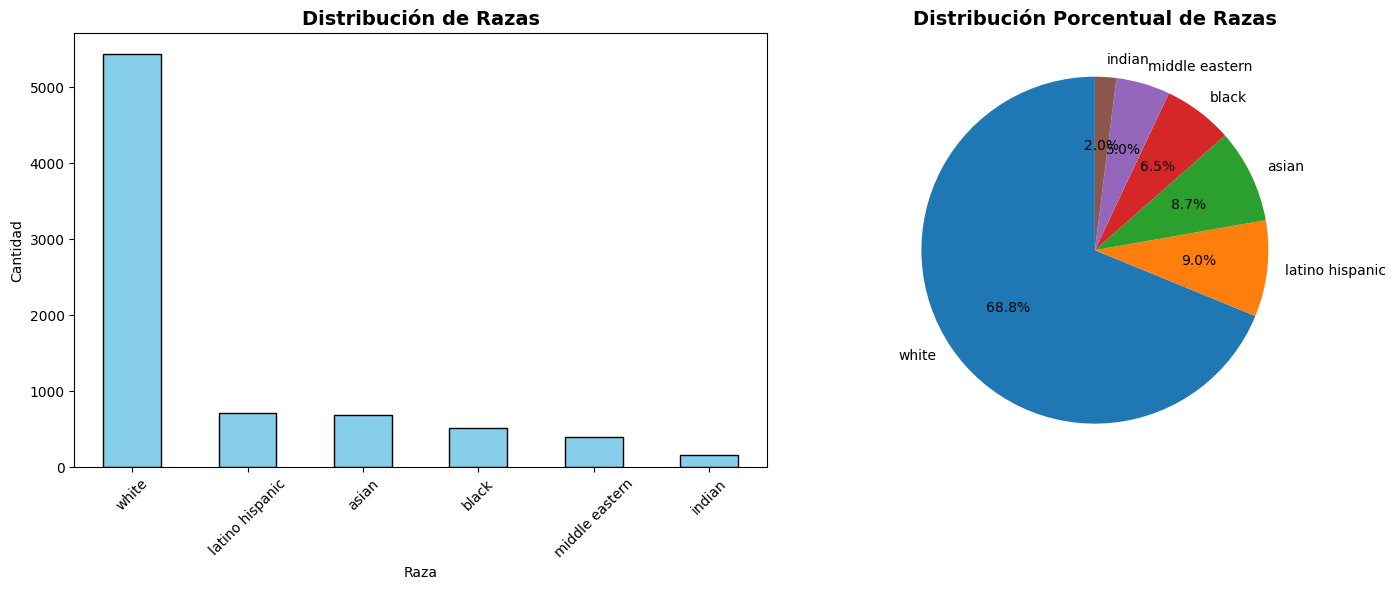

In [3]:
# Análisis de distribución de razas
print("Distribución de razas:")
race_counts = df['race'].value_counts()
print(race_counts)

print(f"\nPorcentaje de distribución:")
race_percentages = df['race'].value_counts(normalize=True) * 100
print(race_percentages.round(2))

# Visualización de distribución de razas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
race_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Razas', fontsize=14, fontweight='bold')
ax1.set_xlabel('Raza')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=45)

# Gráfico de torta
race_percentages.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribución Porcentual de Razas', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()


Métricas de rendimiento por raza (threshold=0.997):
              race  samples  threshold  accuracy  precision  recall  f1_score  \
0            white     5441      0.997    0.9620     0.9612  0.9721    0.9667   
1           indian      157      0.997    0.9745     0.9403  1.0000    0.9692   
2            asian      690      0.997    0.9797     0.9880  0.9786    0.9833   
3  latino hispanic      709      0.997    0.9535     0.9432  0.9707    0.9567   
4   middle eastern      398      0.997    0.9472     0.9423  0.9561    0.9492   
5            black      513      0.997    0.9591     0.9448  0.9864    0.9652   

      auc  specificity  sensitivity  true_positives  true_negatives  \
0  0.9835       0.9486       0.9721            3001            2233   
1  0.9997       0.9574       1.0000              63              90   
2  0.9948       0.9814       0.9786             412             264   
3  0.9862       0.9339       0.9707             365             311   
4  0.9803       0.9378   

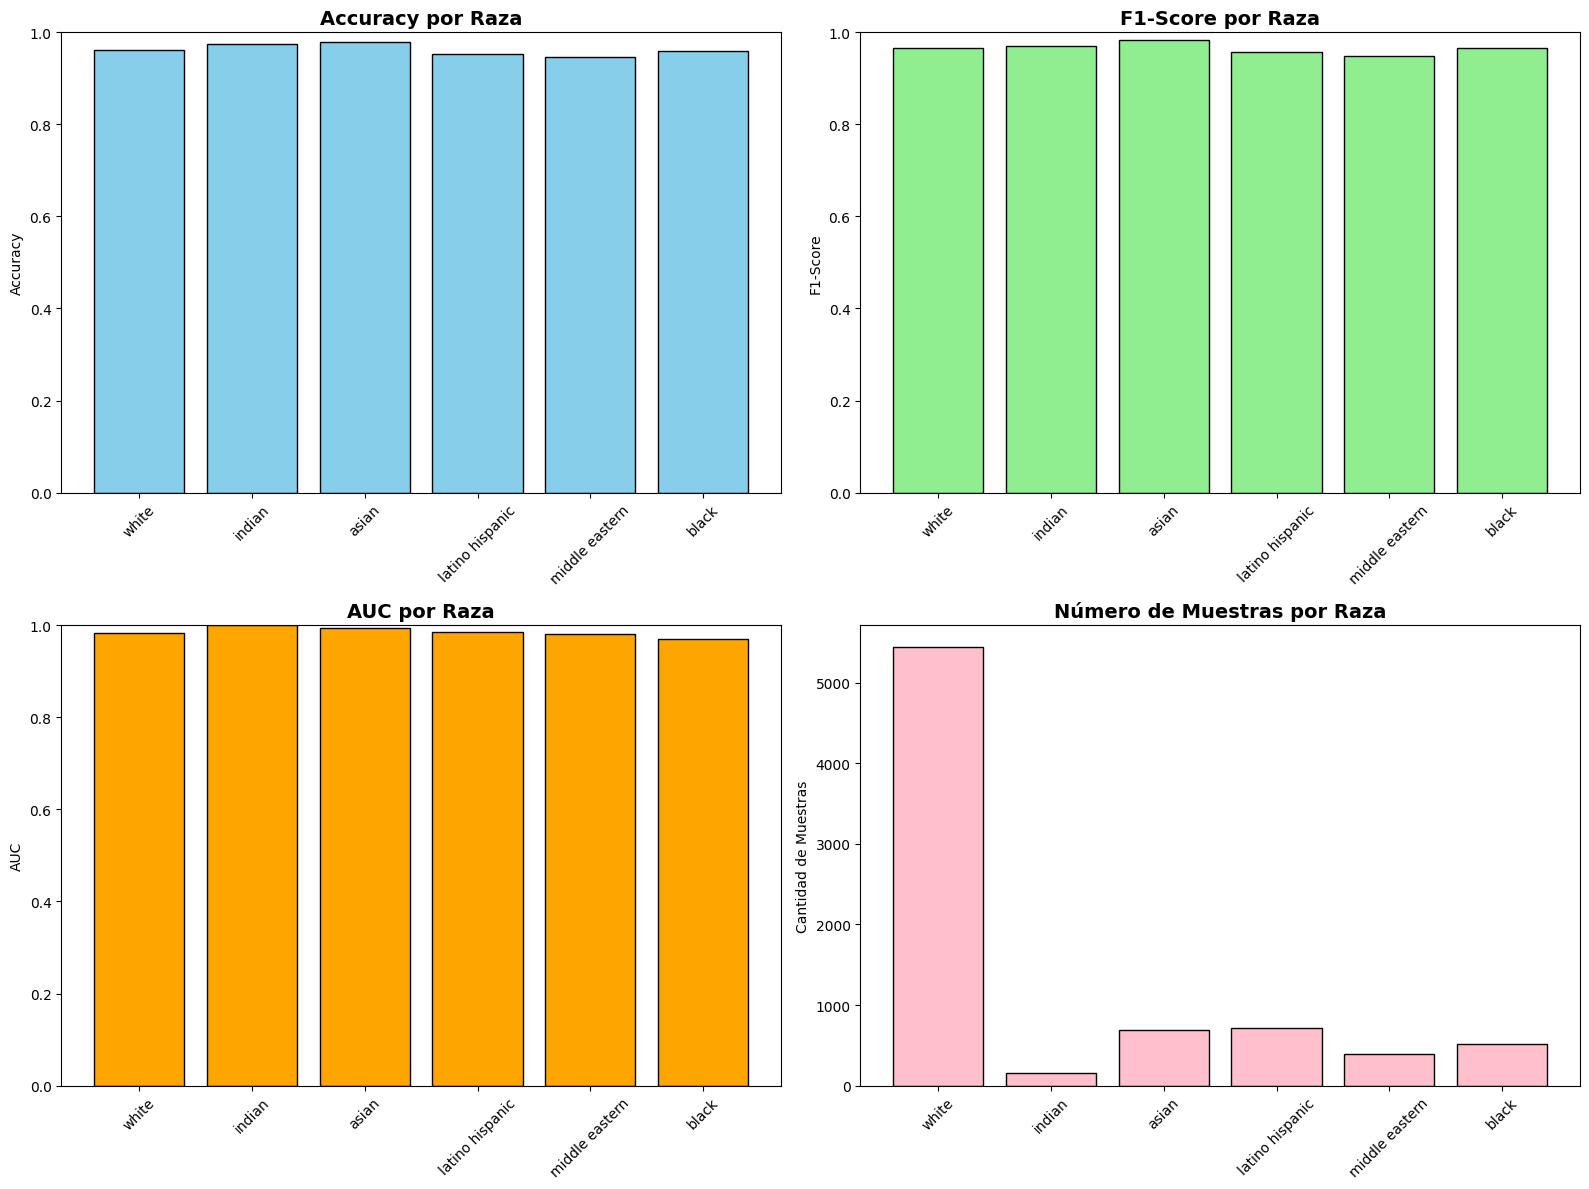

In [4]:
# Análisis de rendimiento por raza
def calculate_metrics_by_race(df, threshold=0.997):
    """Calcula métricas de rendimiento para cada raza usando un threshold personalizado"""
    results = []

    for race in df['race'].unique():
        race_data = df[df['race'] == race]
        if len(race_data) < 10:  # Skip races with very few samples
            continue

        y_true_race = race_data['label']
        y_prob_race = race_data['prob_live']

        # Aplicar threshold a las probabilidades para obtener predicciones
        y_pred_race = (y_prob_race >= threshold).astype(int)

        # Calcular métricas
        accuracy = accuracy_score(y_true_race, y_pred_race)
        precision = precision_score(y_true_race, y_pred_race, zero_division=0)
        recall = recall_score(y_true_race, y_pred_race, zero_division=0)
        f1 = f1_score(y_true_race, y_pred_race, zero_division=0)
        auc = roc_auc_score(y_true_race, y_prob_race) if len(y_true_race.unique()) > 1 else 0

        # Calcular métricas adicionales específicas del threshold
        tn, fp, fn, tp = confusion_matrix(y_true_race, y_pred_race).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'race': race,
            'samples': len(race_data),
            'threshold': threshold,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc': auc,
            'specificity': specificity,
            'sensitivity': sensitivity,
            'true_positives': tp,
            'true_negatives': tn,
            'false_positives': fp,
            'false_negatives': fn
        })

    return pd.DataFrame(results)

# Calcular métricas por raza con threshold personalizado
threshold = 0.997
metrics_by_race = calculate_metrics_by_race(df, threshold=threshold)
print(f"Métricas de rendimiento por raza (threshold={threshold}):")
print(metrics_by_race.round(4))

# Visualización de métricas por raza
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy por raza
axes[0,0].bar(metrics_by_race['race'], metrics_by_race['accuracy'],
              color='skyblue', edgecolor='black')
axes[0,0].set_title('Accuracy por Raza', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim(0, 1)

# F1-Score por raza
axes[0,1].bar(metrics_by_race['race'], metrics_by_race['f1_score'],
              color='lightgreen', edgecolor='black')
axes[0,1].set_title('F1-Score por Raza', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim(0, 1)

# AUC por raza
axes[1,0].bar(metrics_by_race['race'], metrics_by_race['auc'],
              color='orange', edgecolor='black')
axes[1,0].set_title('AUC por Raza', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('AUC')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim(0, 1)

# Número de muestras por raza
axes[1,1].bar(metrics_by_race['race'], metrics_by_race['samples'],
              color='pink', edgecolor='black')
axes[1,1].set_title('Número de Muestras por Raza', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Cantidad de Muestras')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [5]:
# Análisis de sesgo y fairness
print("=== ANÁLISIS DE SESGO Y FAIRNESS ===")

# Calcular diferencias en rendimiento
overall_accuracy = accuracy_score(df['label'], df['pred_argmax'])
print(f"Accuracy general: {overall_accuracy:.4f}")

print("\nDiferencias en accuracy por raza:")
for _, row in metrics_by_race.iterrows():
    diff = row['accuracy'] - overall_accuracy
    print(f"{row['race']}: {row['accuracy']:.4f} (diferencia: {diff:+.4f})")

# Identificar razas con mayor sesgo
bias_threshold = 0.05  # 5% de diferencia
biased_races = metrics_by_race[abs(metrics_by_race['accuracy'] - overall_accuracy) > bias_threshold]
print(f"\nRazas con sesgo significativo (>5% diferencia):")
if len(biased_races) > 0:
    print(biased_races[['race', 'accuracy', 'samples']].round(4))
else:
    print("No se encontraron razas con sesgo significativo")

# Análisis de errores por raza
print("\nAnálisis de errores por raza:")
error_analysis = []
for race in df['race'].unique():
    race_data = df[df['race'] == race]
    if len(race_data) < 10:
        continue

    errors = race_data['label'] != race_data['pred_argmax']
    error_rate = errors.sum() / len(errors)

    # Errores por tipo (falsos positivos y falsos negativos)
    fp = ((race_data['label'] == 0) & (race_data['pred_argmax'] == 1)).sum()
    fn = ((race_data['label'] == 1) & (race_data['pred_argmax'] == 0)).sum()

    error_analysis.append({
        'race': race,
        'samples': len(race_data),
        'error_rate': error_rate,
        'false_positives': fp,
        'false_negatives': fn,
        'fp_rate': fp / len(race_data[race_data['label'] == 0]) if (race_data['label'] == 0).sum() > 0 else 0,
        'fn_rate': fn / len(race_data[race_data['label'] == 1]) if (race_data['label'] == 1).sum() > 0 else 0
    })

error_df = pd.DataFrame(error_analysis)
print(error_df.round(4))


=== ANÁLISIS DE SESGO Y FAIRNESS ===
Accuracy general: 0.9121

Diferencias en accuracy por raza:
white: 0.9620 (diferencia: +0.0498)
indian: 0.9745 (diferencia: +0.0624)
asian: 0.9797 (diferencia: +0.0676)
latino hispanic: 0.9535 (diferencia: +0.0413)
middle eastern: 0.9472 (diferencia: +0.0351)
black: 0.9591 (diferencia: +0.0470)

Razas con sesgo significativo (>5% diferencia):
     race  accuracy  samples
1  indian    0.9745      157
2   asian    0.9797      690

Análisis de errores por raza:
              race  samples  error_rate  false_positives  false_negatives  \
0            white     5441      0.0820              431               15   
1           indian      157      0.2293               36                0   
2            asian      690      0.0449               31                0   
3  latino hispanic      709      0.1241               87                1   
4   middle eastern      398      0.0905               35                1   
5            black      513      0.113

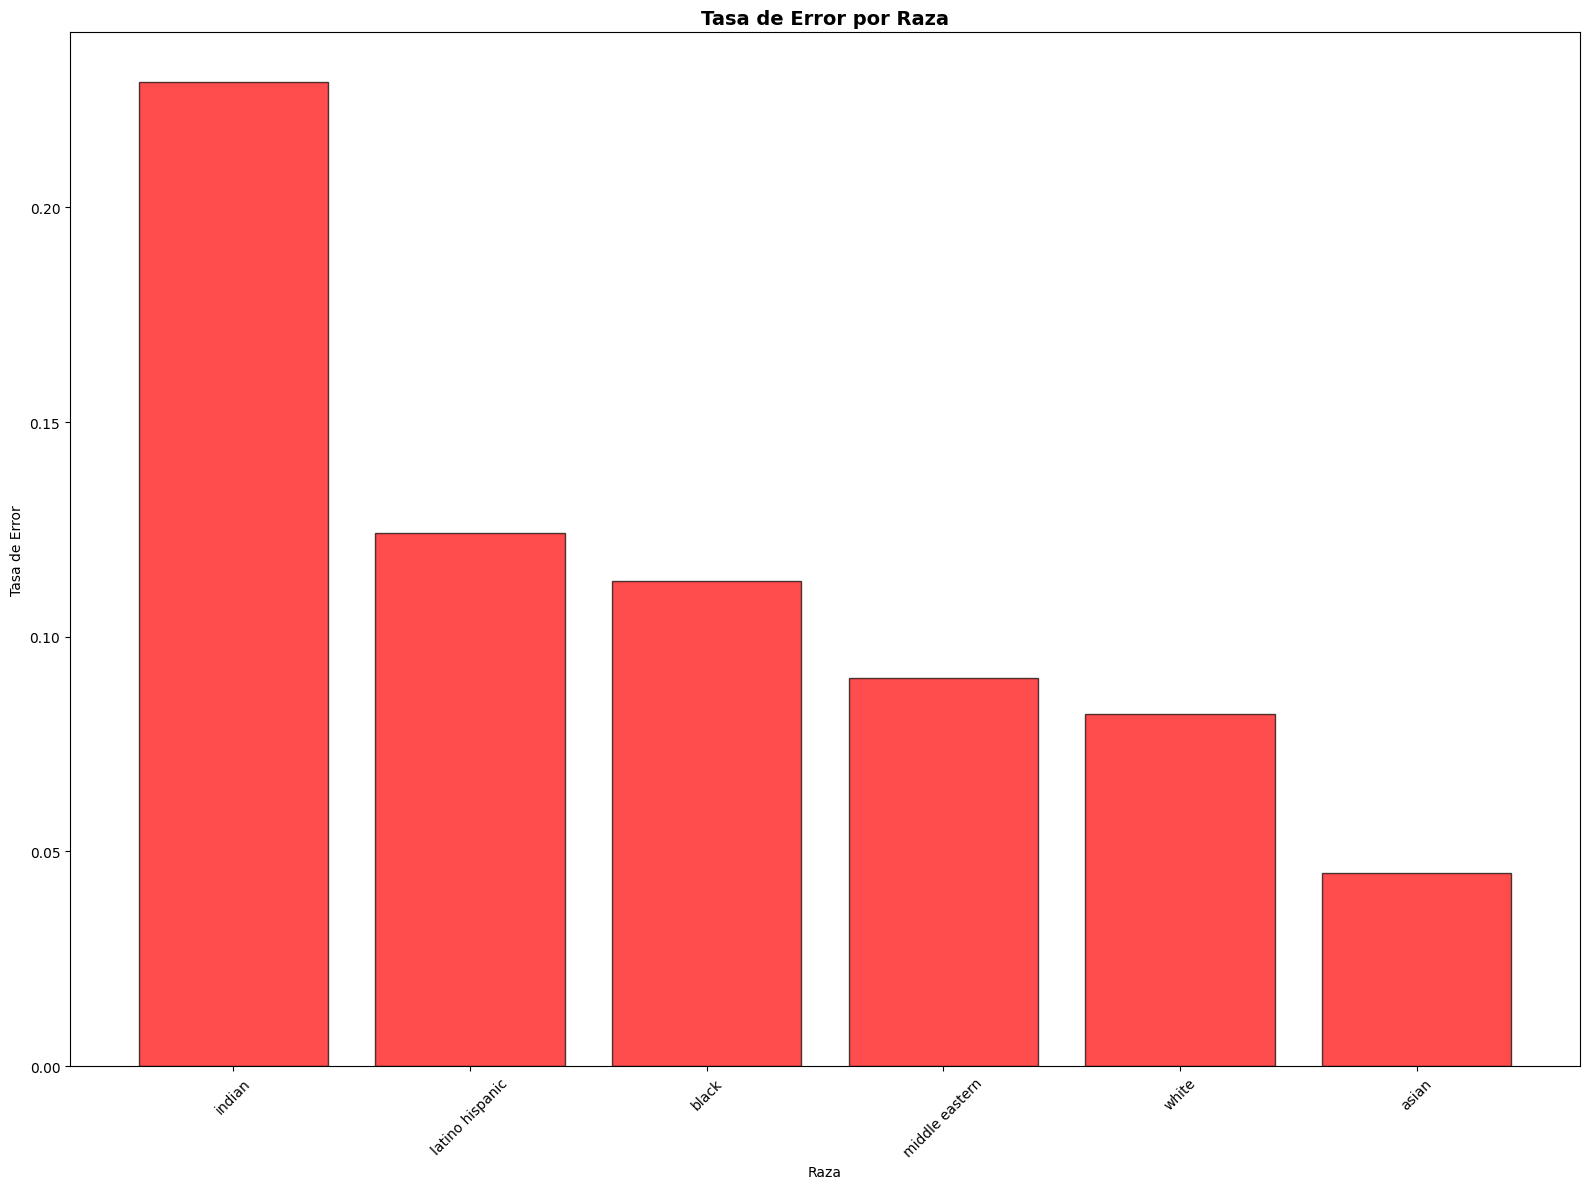

In [10]:
# Análisis de distribución de probabilidades por raza
fig, axes = plt.subplots(figsize=(16, 12))




# Gráfico de barras de tasas de error
error_df_sorted = error_df.sort_values('error_rate', ascending=False)
axes.bar(error_df_sorted['race'], error_df_sorted['error_rate'],
              color='red', alpha=0.7, edgecolor='black')
axes.set_title('Tasa de Error por Raza', fontsize=14, fontweight='bold')
axes.set_xlabel('Raza')
axes.set_ylabel('Tasa de Error')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [12]:
# Resumen final del análisis
print("=== RESUMEN FINAL DEL ANÁLISIS ===")

print(f"\n📊 INFORMACIÓN GENERAL:")
print(f"• Total de muestras: {len(df):,}")
print(f"• Accuracy general: {overall_accuracy:.4f}")
print(f"• Razas identificadas: {len(df['race'].unique())}")

print(f"\n🎯 RENDIMIENTO POR RAZA:")
best_race = metrics_by_race.loc[metrics_by_race['accuracy'].idxmax()]
worst_race = metrics_by_race.loc[metrics_by_race['accuracy'].idxmin()]
print(f"• Mejor rendimiento: {best_race['race']} (Accuracy: {best_race['accuracy']:.4f})")
print(f"• Peor rendimiento: {worst_race['race']} (Accuracy: {worst_race['accuracy']:.4f})")
print(f"• Diferencia máxima: {best_race['accuracy'] - worst_race['accuracy']:.4f}")

print(f"\n⚖️ ANÁLISIS DE SESGO:")
max_bias = abs(metrics_by_race['accuracy'] - overall_accuracy).max()
print(f"• Sesgo máximo: {max_bias:.4f}")
if max_bias > 0.05:
    print("⚠️  Se detectó sesgo significativo en algunas razas")
else:
    print("✅ No se detectó sesgo significativo")

print(f"\n📈 RECOMENDACIONES:")
if max_bias > 0.1:
    print("• Considerar técnicas de debiasing")
    print("• Revisar el balance del dataset de entrenamiento")
    print("• Implementar métricas de fairness específicas")
else:
    print("• El modelo muestra rendimiento relativamente equitativo")
    print("• Continuar monitoreando el rendimiento por subgrupos")

# Guardar resultados
results_summary = {
    'total_samples': len(df),
    'overall_accuracy': overall_accuracy,
    'num_races': len(df['race'].unique()),
    'max_bias': max_bias,
    'best_race': best_race['race'],
    'worst_race': worst_race['race'],
    'accuracy_range': best_race['accuracy'] - worst_race['accuracy']
}

print(f"\n💾 Resultados guardados en 'results_summary' para uso posterior")


=== RESUMEN FINAL DEL ANÁLISIS ===

📊 INFORMACIÓN GENERAL:
• Total de muestras: 7,908
• Accuracy general: 0.9121
• Razas identificadas: 6

🎯 RENDIMIENTO POR RAZA:
• Mejor rendimiento: asian (Accuracy: 0.9797)
• Peor rendimiento: middle eastern (Accuracy: 0.9472)
• Diferencia máxima: 0.0325

⚖️ ANÁLISIS DE SESGO:
• Sesgo máximo: 0.0676
⚠️  Se detectó sesgo significativo en algunas razas

📈 RECOMENDACIONES:
• El modelo muestra rendimiento relativamente equitativo
• Continuar monitoreando el rendimiento por subgrupos

💾 Resultados guardados en 'results_summary' para uso posterior


In [13]:
results_summary

{'total_samples': 7908,
 'overall_accuracy': 0.9121143146181082,
 'num_races': 6,
 'max_bias': 0.06759583030942806,
 'best_race': 'asian',
 'worst_race': 'middle eastern',
 'accuracy_range': np.float64(0.03247396402301361)}